<a href="https://colab.research.google.com/github/Deepikadandolu/SumInt_IISc_ex1/blob/main/tumor_svm(rbf)_splitdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

100%|██████████| 86.8M/86.8M [00:03<00:00, 25.4MB/s]

Extracting files...


In [2]:

# Define classes and labels
classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

# Dataset training folder path
train_path = os.path.join(path, "Training")

# Load and preprocess dataset
X = []
Y = []

for cls, label in classes.items():

    class_path = os.path.join(train_path, cls)

    for filename in os.listdir(class_path):

        img_path = os.path.join(class_path, filename)

        img = cv2.imread(img_path, 0)   # grayscale

        if img is not None:
            img = cv2.resize(img, (200, 200))
            X.append(img.flatten() / 255.0)
            Y.append(label)

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

print("Dataset loaded successfully")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Dataset loaded successfully
X shape: (2870, 40000)
Y shape: (2870,)


In [3]:
# Split dataset into 20% training and 80% testing
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.8
)

# Apply PCA
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train SVM
sv = SVC()

sv.fit(pca_train, ytrain)

# Evaluate model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("20-80 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

20-80 Split
Training Score: 0.9564459930313589
Testing Score: 0.7282229965156795


In [4]:
# Split dataset into 40% training and 60% testing
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.6
)

# Apply PCA
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train SVM
sv = SVC()

sv.fit(pca_train, ytrain)

# Evaluate model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("40-60 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

40-60 Split
Training Score: 0.9599303135888502
Testing Score: 0.7700348432055749


In [5]:
# Split dataset into 60% training and 40% testing
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.4
)

# Apply PCA
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train SVM
sv = SVC()

sv.fit(pca_train, ytrain)

# Evaluate model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("60-40 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

60-40 Split
Training Score: 0.9657375145180023
Testing Score: 0.8031358885017421


In [6]:
# Split dataset into 80% training and 20% testing
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.2
)

# Apply PCA
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train SVM
sv = SVC()

sv.fit(pca_train, ytrain)

# Evaluate model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)

print("80-20 Split")
print("Training Score:", train_score)
print("Testing Score:", test_score)

80-20 Split
Training Score: 0.9677700348432056
Testing Score: 0.8118466898954704


In [7]:
def display_samples(folder, title, model, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for filename in os.listdir(folder)[:num_samples]:
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200))
        img_flat = img.flatten() / 255.0
        prediction = model.predict(pca.transform([img_flat]))
        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

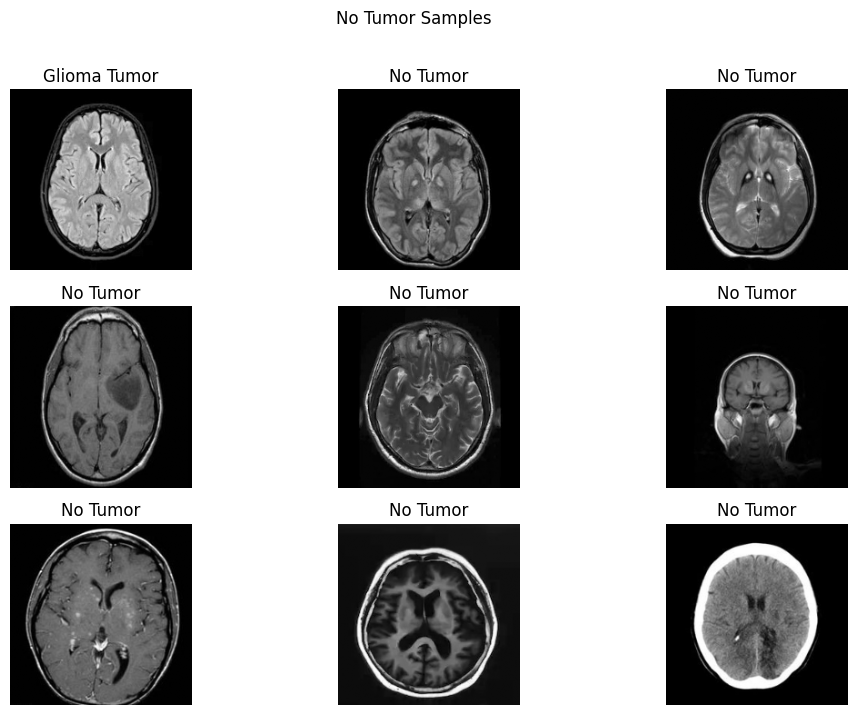

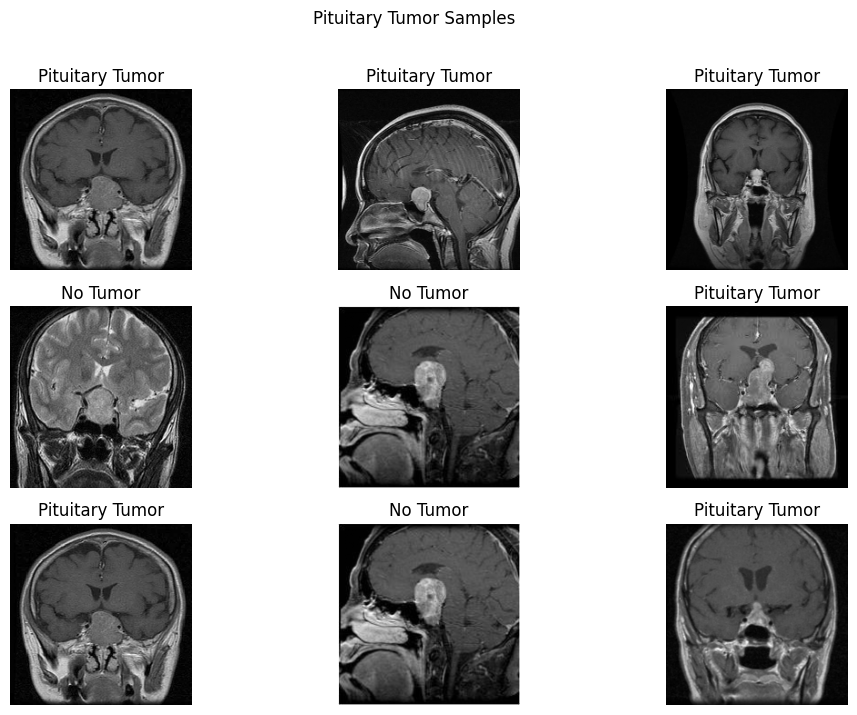

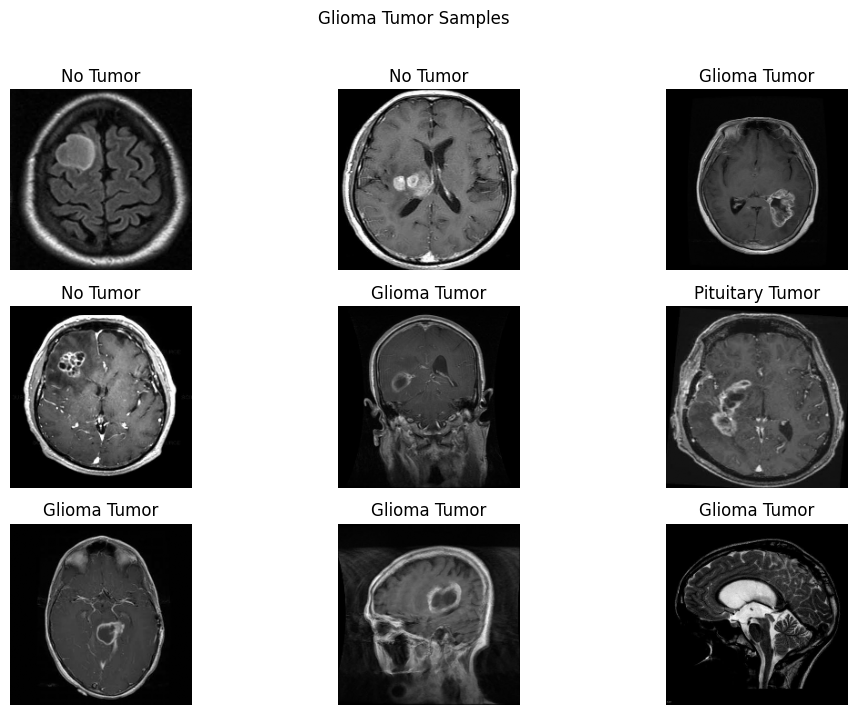

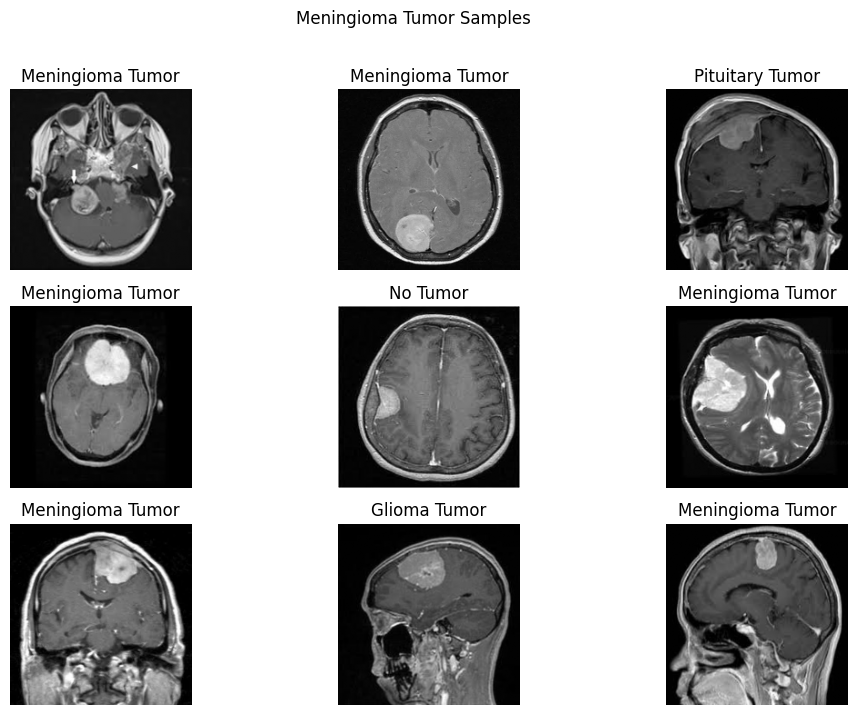

In [8]:
# Define class labels
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}

# Get the base path for the testing dataset
test_path = os.path.join(path, "Testing")

# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = os.path.join(test_path, tumor_folder)
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title, sv)

In [ ]:
import pandas as pd

# Different training splits

train_sizes = [0.2, 0.4, 0.6, 0.8]

for train_size in train_sizes:

    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=10,
        stratify=Y
    )

    pca = PCA(n_components=0.98)

    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)

    svm_rbf = SVC(kernel='rbf')

    svm_rbf.fit(pca_train, ytrain)

    train_score = svm_rbf.score(pca_train, ytrain)
    test_score = svm_rbf.score(pca_test, ytest)

    tumor_counts = {
        dec[label]: np.sum(ytrain == label)
        for label in classes.values()
    }

    table_data = {
        'Index': range(1, len(classes) + 1),
        'Tumor Type': list(tumor_counts.keys()),
        'Count': list(tumor_counts.values())
    }

    tumor_table = pd.DataFrame(table_data)

    styled_table = tumor_table.style.set_properties(
        **{
            'border': '3px solid black',
            'text-align': 'center'
        }
    )

    print(f"\nRBF Kernel - {int(train_size*100)}% Training Data")
    print("Training Score:", train_score)
    print("Testing Score:", test_score)

    display(styled_table)


RBF Kernel - 20% Training Data
Training Score: 0.9547038327526133
Testing Score: 0.7138501742160279


,Index,Tumor Type,Count
0,1,No Tumor,79
1,2,Pituitary Tumor,166
2,3,Glioma Tumor,165
3,4,Meningioma Tumor,164



RBF Kernel - 40% Training Data
Training Score: 0.9494773519163763
Testing Score: 0.778164924506388


,Index,Tumor Type,Count
0,1,No Tumor,158
1,2,Pituitary Tumor,331
2,3,Glioma Tumor,330
3,4,Meningioma Tumor,329



RBF Kernel - 60% Training Data
Training Score: 0.9610917537746806
Testing Score: 0.8179442508710801


,Index,Tumor Type,Count
0,1,No Tumor,237
1,2,Pituitary Tumor,496
2,3,Glioma Tumor,496
3,4,Meningioma Tumor,493



RBF Kernel - 80% Training Data
Training Score: 0.9625435540069687
Testing Score: 0.8327526132404182


,Index,Tumor Type,Count
0,1,No Tumor,316
1,2,Pituitary Tumor,662
2,3,Glioma Tumor,661
3,4,Meningioma Tumor,657


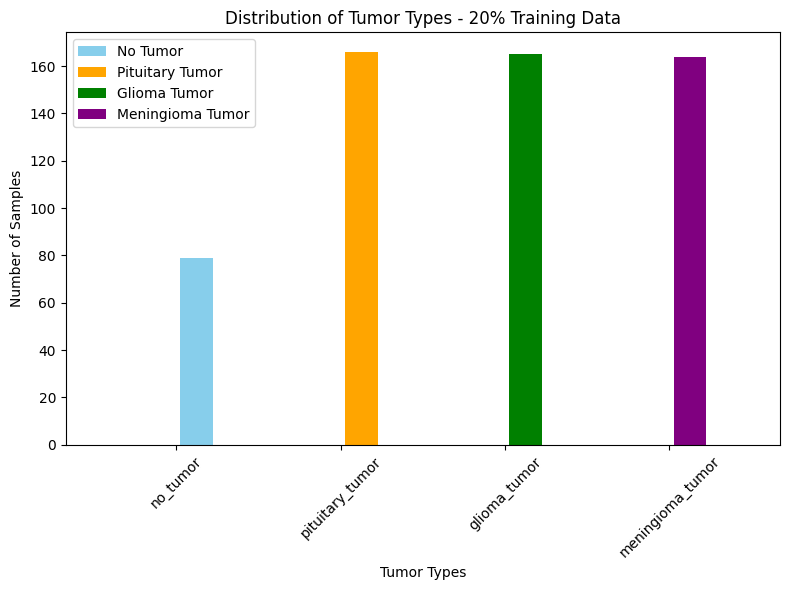

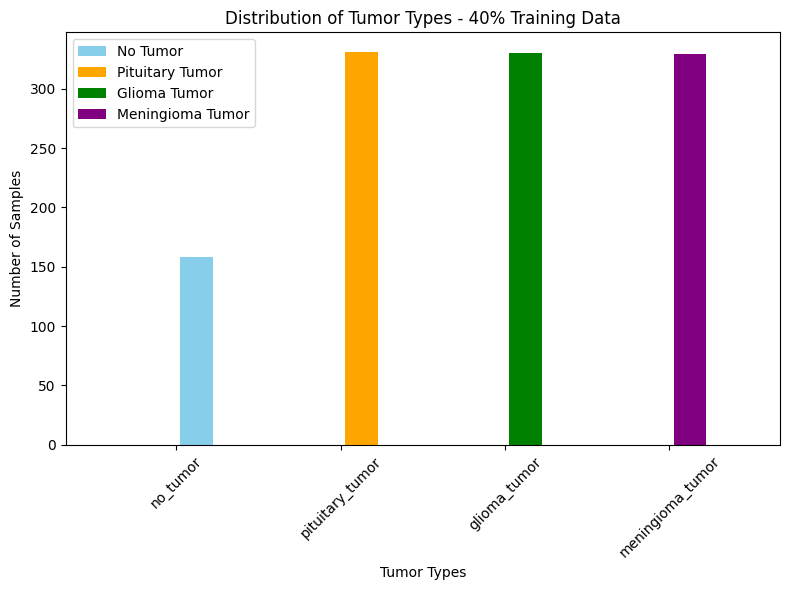

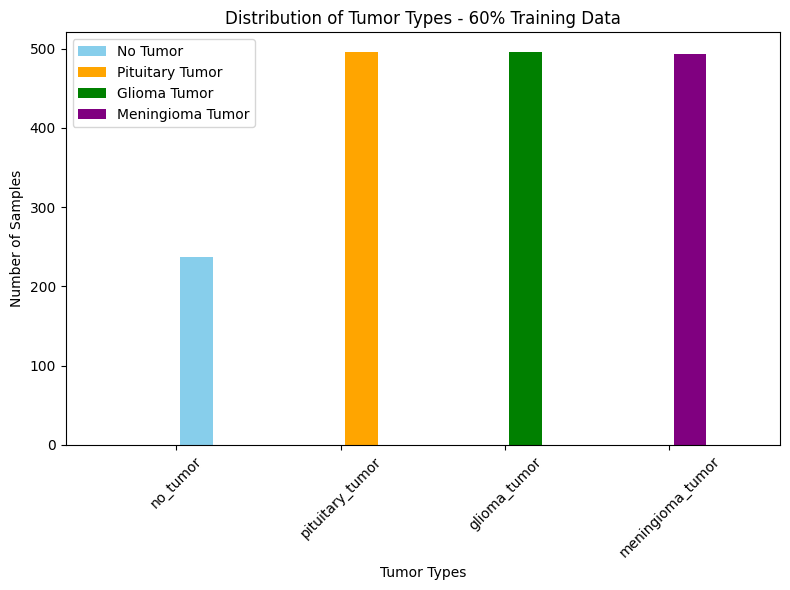

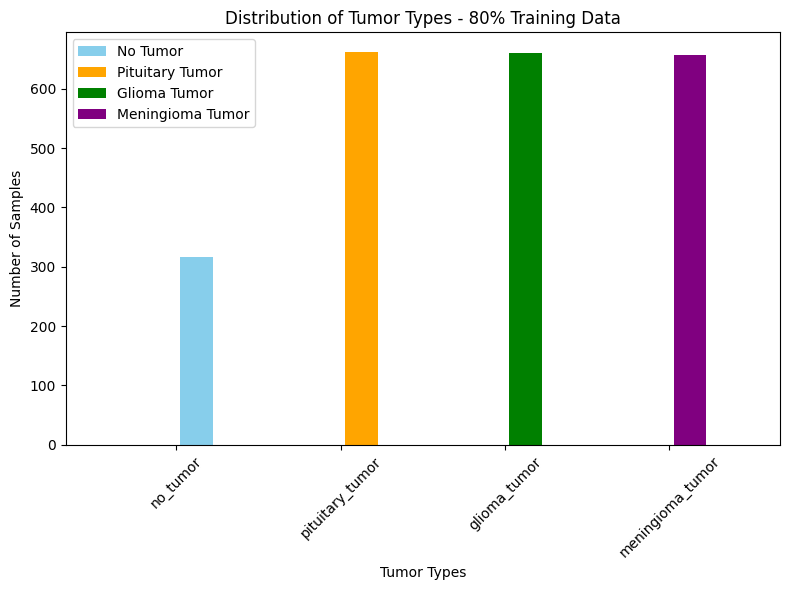

In [9]:
# Create histogram for different training splits using RBF kernel

colors = ['skyblue', 'orange', 'green', 'purple']

train_sizes = [0.2, 0.4, 0.6, 0.8]

for train_size in train_sizes:

    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=10,
        stratify=Y
    )

    tumor_labels = [dec[label] for label in ytrain]

    plt.figure(figsize=(8, 6))

    for label, color in zip(classes.values(), colors):

        plt.hist(
            np.array(tumor_labels)[ytrain == label],
            bins=len(classes),
            align='mid',
            rwidth=0.8,
            color=color,
            label=dec[label]
        )

    plt.xlabel('Tumor Types')

    plt.ylabel('Number of Samples')

    plt.title(
        f'Distribution of Tumor Types - {int(train_size*100)}% Training Data'
    )

    plt.xticks(
        range(len(classes)),
        list(classes.keys()),
        rotation=45
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np

train_sizes = [0.2, 0.4, 0.6, 0.8]

for train_size in train_sizes:

    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=10,
        stratify=Y
    )

    pca = PCA(n_components=0.98)

    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)

    svm_rbf = SVC(kernel='rbf')

    svm_rbf.fit(pca_train, ytrain)

    ypred_rbf = svm_rbf.predict(pca_test)

    accuracy_rbf = accuracy_score(ytest, ypred_rbf)

    f1_rbf = f1_score(
        ytest,
        ypred_rbf,
        average='weighted'
    )

    cm_rbf = confusion_matrix(ytest, ypred_rbf)

    sensitivity_rbf = np.mean(
        cm_rbf.diagonal() / cm_rbf.sum(axis=1)
    )

    specificity_rbf = np.mean([
        (np.sum(cm_rbf) - (
            cm_rbf[i,:].sum() +
            cm_rbf[:,i].sum() -
            cm_rbf[i,i]
        )) /
        (np.sum(cm_rbf) - cm_rbf[i,:].sum())
        for i in range(len(cm_rbf))
    ])

    print(f"\nRBF Kernel - {int(train_size*100)}% Training Data")

    print("Accuracy:", accuracy_rbf)

    print("F1-Score:", f1_rbf)

    print("Sensitivity:", sensitivity_rbf)

    print("Specificity:", specificity_rbf)


RBF Kernel - 20% Training Data
Accuracy: 0.7195121951219512
F1-Score: 0.7088073767038985
Sensitivity: 0.6951745115599481
Specificity: 0.9038914831346023

RBF Kernel - 40% Training Data
Accuracy: 0.7723577235772358
F1-Score: 0.7655105831384463
Sensitivity: 0.7555063715620153
Specificity: 0.9226747134246965

RBF Kernel - 60% Training Data
Accuracy: 0.8118466898954704
F1-Score: 0.8083489387544537
Sensitivity: 0.8056168997865031
Specificity: 0.936381801743253

RBF Kernel - 80% Training Data
Accuracy: 0.837979094076655
F1-Score: 0.8360225509814826
Sensitivity: 0.8244533947065592
Specificity: 0.94495937368798


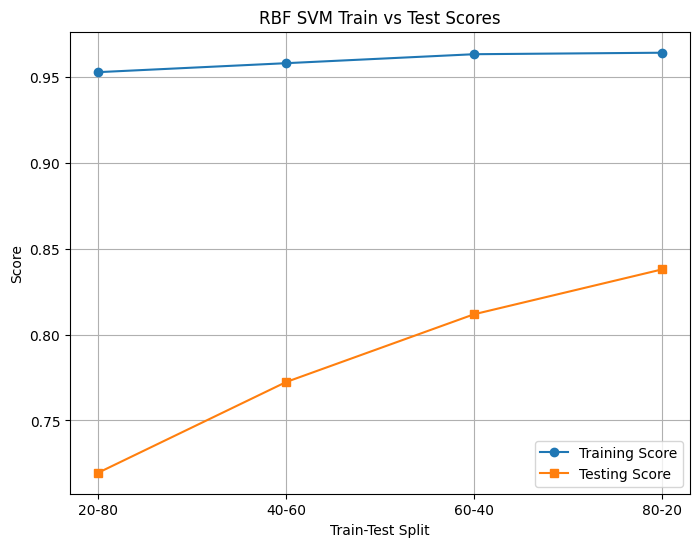

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt

train_sizes = [0.2, 0.4, 0.6, 0.8]
split_labels = ['20-80', '40-60', '60-40', '80-20']
train_scores = []
test_scores = []
for train_size in train_sizes:
    xtrain, xtest, ytrain, ytest = train_test_split(
        X,
        Y,
        train_size=train_size,
        random_state=10,
        stratify=Y)
    pca = PCA(n_components=0.98)
    pca_train = pca.fit_transform(xtrain)
    pca_test = pca.transform(xtest)
    sv = SVC(kernel='rbf')
    sv.fit(pca_train, ytrain)
    train_score = sv.score(pca_train, ytrain)
    test_score = sv.score(pca_test, ytest)
    train_scores.append(train_score)
    test_scores.append(test_score)
plt.figure(figsize=(8, 6))
plt.plot(
    split_labels,
    train_scores,
    marker='o',
    label='Training Score')
plt.plot(
    split_labels,
    test_scores,
    marker='s',
    label='Testing Score')
plt.xlabel('Train-Test Split')
plt.ylabel('Score')
plt.title('RBF SVM Train vs Test Scores')
plt.legend()
plt.grid(True)
plt.show()